In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    avg, count, sum, col, to_date, expr, rank, dense_rank, lead, lag,
    percent_rank, ntile, row_number, cume_dist, first_value, last_value
)
from pyspark.sql.window import Window
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

# Initialize Spark session
spark = SparkSession.builder.appName("Flight Delay Analysis").getOrCreate()

# Set file paths
delays_file_path = "departuredelays.csv"
airports_file_path = "airport-codes-na.txt"

# Load datasets with correct options
airports_df = (spark.read
    .format("csv")
    .options(header="true", inferSchema="true", sep="\t")
    .load(airports_file_path))

delays_df = (spark.read
    .format("csv")
    .options(header="true")
    .load(delays_file_path)
    .withColumn("delay", expr("CAST(delay as INT)"))
    .withColumn("distance", expr("CAST(distance as INT)")))

In [ ]:
airports_df.show(5)
delays_df.show(5)

+----------+-----+-------+----+
|      City|State|Country|IATA|
+----------+-----+-------+----+
|Abbotsford|   BC| Canada| YXX|
|  Aberdeen|   SD|    USA| ABR|
|   Abilene|   TX|    USA| ABI|
|     Akron|   OH|    USA| CAK|
|   Alamosa|   CO|    USA| ALS|
+----------+-----+-------+----+
only showing top 5 rows

+--------+-----+--------+------+-----------+
|    date|delay|distance|origin|destination|
+--------+-----+--------+------+-----------+
|01011245|    6|     602|   ABE|        ATL|
|01020600|   -8|     369|   ABE|        DTW|
|01021245|   -2|     602|   ABE|        ATL|
|01020605|   -4|     602|   ABE|        ATL|
|01031245|   -4|     602|   ABE|        ATL|
+--------+-----+--------+------+-----------+
only showing top 5 rows



In [ ]:
# Clean and select relevant columns
delays_df = delays_df.select("date", "delay", "distance", "origin", "destination")
airports_df = airports_df.select("City", "State", "Country", "IATA")

# Inner Join - Match delays with airport information
joined_df = delays_df.join(airports_df, delays_df.origin == airports_df.IATA, "inner")

# Aggregation - Average delay by city
avg_delay_city = joined_df.groupBy("City").agg(avg("delay").alias("avg_delay")).orderBy("avg_delay", ascending=False)



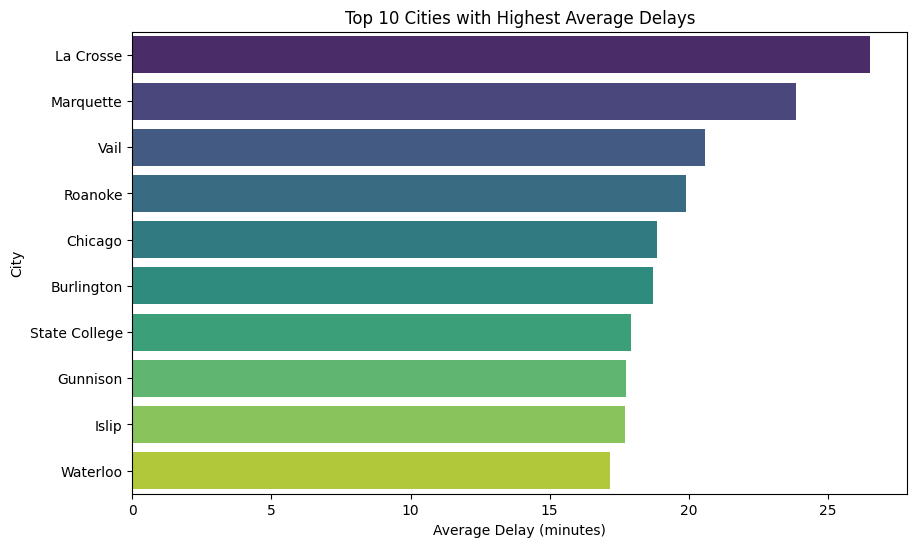

In [ ]:
# Visualization 1: Bar Chart - Average Delay by City
avg_delay_pd = avg_delay_city.limit(10).toPandas()
plt.figure(figsize=(10, 6))
sns.barplot(x='avg_delay', y='City', data=avg_delay_pd, palette='viridis', hue='City', legend=False)
plt.title('Top 10 Cities with Highest Average Delays')
plt.xlabel('Average Delay (minutes)')
plt.ylabel('City')
plt.show()


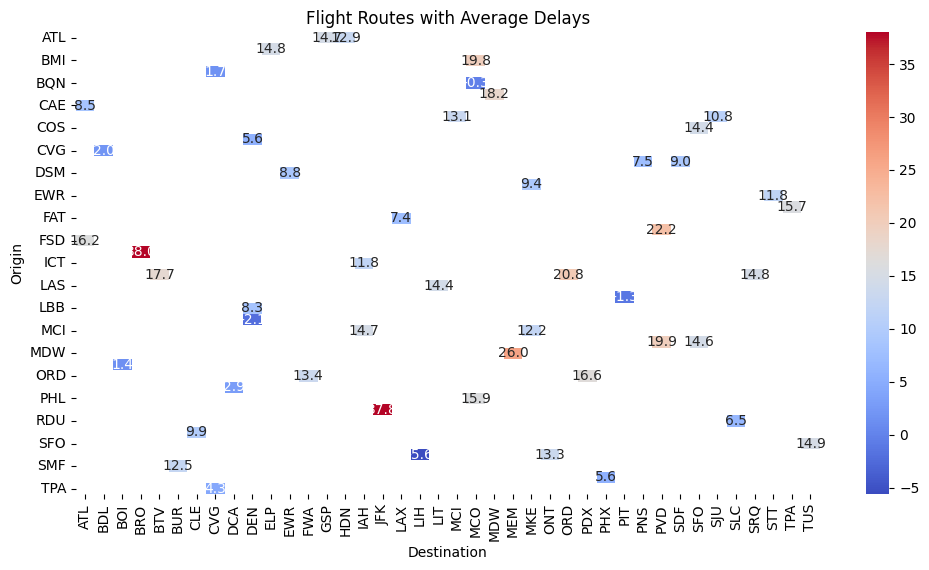

In [ ]:

# Left Outer Join - Include all flights with possible missing airport data
route_df = delays_df.join(airports_df, delays_df.origin == airports_df.IATA, "left_outer")
route_df = route_df.groupBy("origin", "destination").agg(avg("delay").alias("avg_delay"), count("*").alias("flight_count"))

# Visualization 2: Heatmap - Flight Routes with Average Delays
route_pd = route_df.limit(50).toPandas()
plt.figure(figsize=(12, 6))
sns.heatmap(route_pd.pivot(index='origin', columns='destination', values='avg_delay'), cmap='coolwarm', annot=True, fmt='.1f')
plt.title('Flight Routes with Average Delays')
plt.xlabel('Destination')
plt.ylabel('Origin')
plt.show()

In [ ]:
# Convert date column and apply window functions
delays_df = delays_df.withColumn("date", to_date(col("date"), "yyyyMMdd"))
window_spec = Window.partitionBy("origin").orderBy("date")

# Apply Window Functions
delays_df = delays_df.withColumn("prev_delay", lag("delay").over(window_spec))
delays_df = delays_df.withColumn("next_delay", lead("delay").over(window_spec))

# Ranking Functions
delays_df = delays_df.withColumn("rank", rank().over(window_spec))
delays_df = delays_df.withColumn("dense_rank", dense_rank().over(window_spec))
delays_df = delays_df.withColumn("percent_rank", percent_rank().over(window_spec))
delays_df = delays_df.withColumn("ntile", ntile(4).over(window_spec))
delays_df = delays_df.withColumn("row_number", row_number().over(window_spec))

# Analytic Functions
delays_df = delays_df.withColumn("cume_dist", cume_dist().over(window_spec))
delays_df = delays_df.withColumn("first_value", first_value("delay").over(window_spec))
delays_df = delays_df.withColumn("last_value", last_value("delay").over(window_spec))

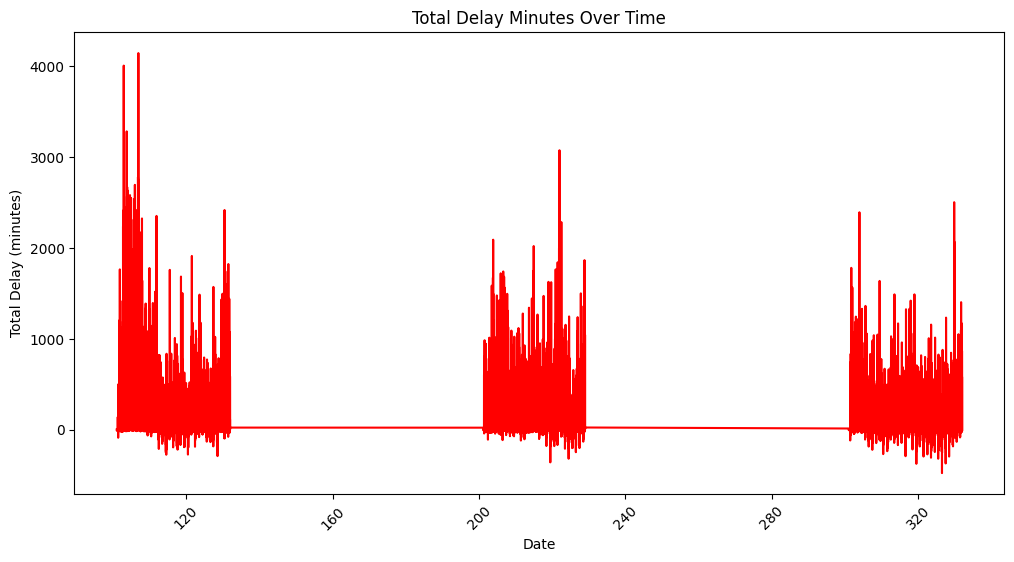

In [ ]:
# Aggregation - Delay Trends Over Time
delay_trend_df = delays_df.groupBy("date").agg(sum("delay").alias("total_delay")).orderBy("date")

# Visualization 3: Line Chart - Total Delay Minutes Over Time
delay_trend_pd = delay_trend_df.toPandas()
plt.figure(figsize=(12, 6))
plt.plot(delay_trend_pd['date'], delay_trend_pd['total_delay'], color='red')
plt.title('Total Delay Minutes Over Time')
plt.xlabel('Date')
plt.ylabel('Total Delay (minutes)')
plt.xticks(rotation=45)
plt.show()